# 1. Импорты

# 2. Функции

In [242]:
def leakage_check(df, col, target='target'):
     """
     сравнивает распределение значений признака и долю nan-значений между
     группами target=0 и target=1. Использую ее для проверки на утечку данных.
     Если распределение слишком чисто разделяет классы
     (квартили не пересекаются, доля пропусков резко отличается),
     это может означать, что признак содержит информацию, недоступную
     на момент подачи заявки, а не реальную связь с риском
     """
     missing_rate = df.groupby(target)[col].apply(lambda x: x.isna().mean())

     if pd.api.types.is_numeric_dtype(df[col]):
          info = df.groupby(target)[col].describe()
     else: 
          info = df.groupby(target)[col].value_counts(normalize=True)

     return info, missing_rate

In [289]:
from scipy.stats import chi2_contingency, ttest_ind

def chi2(column1, column2, data, verbose=True):
    contingency = pd.crosstab(data[column1], data[column2], dropna=False)
    chi2, p_value, dof, expected = chi2_contingency(contingency)
    n = contingency.sum().sum()
    min_dim = min(contingency.shape) - 1
    cramers_v = np.sqrt(chi2 / (n * min_dim))
    noise_floor_v = np.sqrt(dof / n)

    if verbose:
        print(f"p-value = {p_value:.4f}, Cramer's V = {cramers_v:.4f}")
        print(f"ожидаемый уровень V при чистом шуме (H0) = {noise_floor_v:.4f}")
        print(f"expected.min() = {expected.min():.2f}")

    return p_value, cramers_v  


def ttest(column1, column2, data, verbose=True):
    group1 = data[data[column2] == 0][column1]
    group2 = data[data[column2] == 1][column1]
    t_stat, p_value = ttest_ind(group1, group2, nan_policy='omit')
    n1, n2 = group1.notna().sum(), group2.notna().sum()
    df = n1 + n2 - 2
    eta_squared = t_stat**2 / (t_stat**2 + df)

    if verbose:
        print(f"p-value = {p_value:.5f}")
        print(f"η² (eta squared) = {eta_squared:.4f}")

    return p_value, eta_squared


def visualization(data, x, target):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    sns.countplot(data=data, x=x, ax=axes[0])

    sns.barplot(data=data, x=x, y=target, ax=axes[1])
    axes[0].set_title(f'Распределение {x}')
    axes[1].set_title(f'Доля просрочек по {x}')
    axes[1].set_ylabel(f'доля {target}=1')

    plt.tight_layout()
    plt.show()


# 3. Импорт данных

In [263]:
from pathlib import Path

import pandas as pd
import numpy as np

pd.set_option('display.width', 150)

ROOT = Path.cwd()
if not (ROOT / "data").exists() and (ROOT.parent / "data").exists():
    ROOT = ROOT.parent

DATA_DIR = ROOT / "data"
train = pd.read_csv(DATA_DIR / "train.csv")
test = pd.read_csv(DATA_DIR / "test.csv")
transactions = pd.read_csv(DATA_DIR / "transactions.csv")
previous_loans = pd.read_csv(DATA_DIR / "previous_loans.csv")
bureau = pd.read_csv(DATA_DIR / "bureau.csv")

# 4. Предобработка данных

## 4.1. Работа с основной таблицей


In [264]:
# проверяю размеры таблиц 

print("train:", train.shape, train.shape)
print("test:", test.shape, test.shape)
print("buro:", bureau.shape)
print("transactions:", transactions.shape)
print("previous_loans:", previous_loans.shape)


train: (6488, 25) (6488, 25)
test: (2520, 24) (2520, 24)
buro: (24689, 8)
transactions: (353300, 6)
previous_loans: (12762, 7)


In [265]:
# удаляю дубли строк в train, в test их нет

print(f'дубликатов в train = {train.duplicated().sum()}')
print(f'дубликатов в test = {test.duplicated().sum()}')

train = train.drop_duplicates().reset_index(drop=True)

дубликатов в train = 8
дубликатов в test = 0


Feature engineering основной таблицы

In [266]:
train.columns

Index(['application_id', 'client_id', 'employment_type', 'hash_id', 'region_coefficient_extended', 'age', 'incoming_amount',
       'internal_decision_code', 'monthly_income', 'application_date', 'education', 'requested_product', 'channel', 'loan_amount',
       'marketing_segment', 'post_loan_collection_score', 'region_coefficient', 'region', 'interest_rate', 'months_at_job', 'dependents',
       'days_until_first_overdue', 'loan_term_months', 'siberia_northern_score', 'target'],
      dtype='str')

In [267]:
# утечка: признак фактически кодирует факт просрочки

leakage_check(train, 'days_until_first_overdue') 
train = train.drop('days_until_first_overdue', axis=1)
test = test.drop('days_until_first_overdue', axis=1)

In [268]:
# утечка: оценка коллекторов считается после выдачи займа, недоступна на момент заявки

leakage_check(train, 'post_loan_collection_score') 
train = train.drop('post_loan_collection_score', axis=1)
test = test.drop('post_loan_collection_score', axis=1)

In [269]:
# утечка: неизвестно, когда признак фиксируется

leakage_check(train, 'internal_decision_code')
train = train.drop('internal_decision_code', axis=1)
test = test.drop('internal_decision_code', axis=1)

# остальные колонки проверены на проверены аналогично, утечек не обнаружил

In [270]:
# удаляю hash_id, дублирует client_id

train.groupby('hash_id')['client_id'].nunique().value_counts()
train = train.drop('hash_id', axis=1)
test = test.drop('hash_id', axis=1)

# удаляю константу, не несет сигнала для модели
train['region_coefficient'].value_counts(dropna=False)
train = train.drop('region_coefficient', axis=1)

In [272]:
# проверка различия monthly_income и incoming_amount

both = train['monthly_income'].notna() & train['incoming_amount'].notna()
print('оба заполнены:', both.sum())
print('из них совпадают:', (train.loc[both, 'monthly_income'] == train.loc[both, 'incoming_amount']).mean())

# там, где оба значения не nan, они полностью совпадают
# объединение признаков
train['income'] = train['monthly_income'].fillna(train['incoming_amount'])
test['income'] = test['monthly_income'].fillna(test['incoming_amount'])

оба заполнены: 5637
из них совпадают: 1.0


In [273]:
# денежные показатели обычно ассиметричны, устраняю симметрию логарифмированием

print(f"ассиметрия income: {train['income'].skew()}")
print(f"ассиметрия loan_amount: {train['loan_amount'].skew()}")

train['log_income'] = np.log(train['income'] + 1)
test['log_income'] = np.log(test['income'] + 1)

train['log_loan_amount'] = np.log1p(train['loan_amount'])
test['log_loan_amount'] = np.log1p(test['loan_amount'])  

ассиметрия income: 1.809429878655907
ассиметрия loan_amount: 2.0829455188681103


In [274]:
# бининг слобцов с непрерывными значениями для визуализации

train['months_at_job_group'] = pd.cut(train['months_at_job'], bins=[0, 36, 80, 149, 506])
train['log_income_group'] = pd.qcut(train['log_income'], q=4)
train['log_loan_amount_group'] = pd.qcut(train['log_loan_amount'], q=6)
train['loan_term_months_group'] = pd.cut(train['loan_term_months'], bins=[6, 12, 18, 24, 48])
train['interest_rate_group'] = pd.qcut(train['interest_rate'], q=4)
train['siberia_northern_score_group'] = pd.qcut(train['siberia_northern_score'], q=4) 

In [275]:
# создание новых признаков

# платежеспособность
train['loan_by_income'] = train['loan_amount'] / train['income']

# доход на члена семьи
train['income_per_person'] = train['income'] / train['dependents']

## 4.2 Работа с дополнительными таблицами

Таблицы bureau, previous_loans, transactions нельзя просто смержить по client_id, потому что каждому client_id в этих таблицах может соответствовать несколько строк. Данные можно объединить, предварительно сгруппировав их по client_id и вычислив различные показатели (min, max, mean...)

In [276]:
transactions.head()

,client_id,application_id,transaction_date,transaction_category,amount,merchant_risk_level
0,1,100001,2025-10-22,transfer,-1538.95,5.0
1,1,100001,2025-07-10,cash_withdrawal,-1460.46,1.0
2,1,100001,2025-11-01,utilities,-988.50,2.0
3,1,100001,2025-10-10,salary,8578.27,3.0
4,1,100001,2025-12-24,entertainment,-2015.69,2.0


Feature engineering transactions

In [ ]:
transactions['transaction_date'] = pd.to_datetime(transactions['transaction_date'])

# агрегация по числовым признакам
transactions_agg = transactions.groupby('client_id').agg(
    # счет, сумма, среднее, медиана, отклонение всех транзакций
    transactions_count = ('amount', 'count'),
    transactions_amount_sum = ('amount', 'sum'),
    transactions_amount_mean = ('amount', 'mean'),
    transactions_amount_median = ('amount', 'median'),
    transactions_amount_std = ('amount', 'std' ),

    # среднее риска транзакции
    transactions_risk_mean = ('merchant_risk_level', 'mean')

).reset_index()

# считаю долю каждой категории транзакций у каждого клиента 
transactions_category = pd.crosstab(transactions['client_id'], transactions['transaction_category'], normalize='index').reset_index()

# объединяю доли категорий с созданными числовыми признаками
transactions_agg = transactions_agg.merge(transactions_category, on='client_id', how='left')

# временной признак: сколько дней назад была последняя транзакция до подачи заявки

dates = pd.concat([
    train[['application_id', 'application_date']],
    test[['application_id', 'application_date']],
])
dates['application_date'] = pd.to_datetime(dates['application_date'])

transactions_with_date = transactions.merge(dates, on='application_id', how='inner')
transactions_with_date['days_before_application'] = (
    transactions_with_date['application_date'] - transactions_with_date['transaction_date']
).dt.days

recency = transactions_with_date.groupby('client_id')['days_before_application'].min().rename('days_since_last_transactions').reset_index()
transactions_agg = transactions_agg.merge(recency, on='client_id', how='left')

# доходные и расходные признаки

income = transactions.groupby('client_id')['amount'].apply(lambda x: x[x > 0].sum())
expenses = transactions.groupby('client_id')['amount'].apply(lambda x: abs(x[x < 0].sum()))

# отсутствие доходов или расходов может иметь значение для оценки 
no_income = (income == 0).rename('no_income_transactions').astype(int).reset_index()
# no_expenses нет

# денежный поток
cash_flow = (income / expenses).replace([np.inf, -np.inf], np.nan).rename('cash_flow').reset_index()


In [ ]:
# мержу все новые признаки в transactions
transactions_agg = transactions_agg.merge(cash_flow, on='client_id', how='left')
transactions_agg = transactions_agg.merge(no_income, on='client_id', how='left')

# мержу transactions в train и test
train = train.merge(transactions_agg, on='client_id', how='left')
test = test.merge(transactions_agg, on='client_id', how='left')

Feature engineering bureau

In [236]:
bureau.head()

,client_id,bureau_account_id,account_type,opened_days_ago,credit_limit,current_balance,max_dpd_last_12m,bureau_status
0,1,B1_0,credit_card,2410.0,20474.70,5760.10,0.0,active
1,2,B2_1,NaN,2983.0,61748.02,47175.10,1.0,active
2,3,B3_2,auto,943.0,93069.06,40725.25,15.0,active
3,3,B3_3,mortgage,2355.0,173852.51,57974.36,7.0,closed
4,3,B3_4,credit_card,302.0,24037.79,7801.91,1.0,closed


In [284]:
bureau_agg = bureau.groupby('client_id').agg(
    # счет счетов
    bureau_account_id_count = ('bureau_account_id', 'count'),

    #сумма, среднее, максимум, минимум, отклонение кредитного лимита
    credit_limit_sum = ('credit_limit', 'sum'),
    credit_limit_mean = ('credit_limit', 'mean'),
    credit_limit_max = ('credit_limit', 'max'),
    credit_limit_min = ('credit_limit', 'min'),
    credit_limit_std = ('credit_limit', 'std'),

    # сумма, среднее, максимум, минимум баланса
    current_balance_sum = ('current_balance', 'sum'),
    current_balance_mean = ('current_balance', 'mean'),
    current_balance_max = ('current_balance', 'max'),
    current_balance_min = ('current_balance', 'min'),

    # сумма, среднее, максимум, минимум просрочки 
    max_dpd_last_12m_max = ('max_dpd_last_12m', 'max'), 
    max_dpd_last_12m_min = ('max_dpd_last_12m', 'min'), 
    max_dpd_last_12m_mean = ('max_dpd_last_12m', 'mean'),
    max_dpd_last_12m_sum = ('max_dpd_last_12m', 'sum')
    
).reset_index()

# доля активных кредитов
bureau_active_status = bureau.groupby('client_id')['bureau_status'].apply(
    lambda x: (x == 'active').mean()
).rename('bureau_active_status').reset_index()

# доля кредитов по типам
bureau_account_type = pd.crosstab(bureau['client_id'], bureau['account_type'], normalize='index').reset_index()

In [285]:
print(f"кол-во client_id в bureau: {bureau['client_id'].nunique()}")
print(f"кол-во client_id в train и test: {train['client_id'].nunique() + test['client_id'].nunique()}")
print(f"у {train['client_id'].nunique() + test['client_id'].nunique() - bureau['client_id'].nunique()} клиентов нет информации о внешней кредитной истории")

# дабавляю бинарный флаг: имеет ли клиент внешние долги
train['has_bureau'] = train['client_id'].isin(bureau['client_id']).astype(int)
test['has_bureau'] = test['client_id'].isin(bureau['client_id']).astype(int)

кол-во client_id в bureau: 8542
кол-во client_id в train и test: 9000
у 458 клиентов нет информации о внешней кредитной истории


In [286]:
# merge новых признаков с агрегированным bureau
bureau_agg = bureau_agg.merge(bureau_active_status, on='client_id', how='left')
bureau_agg = bureau_agg.merge(bureau_account_type, on='client_id', how='left')

# merge агрегированного bureau с train и test
train = train.merge(bureau_agg, on='client_id', how='left')
test = test.merge(bureau_agg, on='client_id', how='left')

Feature engineering previous_loans

In [287]:
loans_agg = previous_loans.groupby('client_id').agg(
    # количество прошлых займов
    previous_loan_count = ('previous_loan_id', 'count'),

    # сумма, среднее, минимум, максимум прошлых займов
    previous_amount_sum = ('previous_amount', 'sum'),
    previous_amount_mean = ('previous_amount', 'mean'),
    previous_amount_min = ('previous_amount', 'min'),
    previous_amount_max = ('previous_amount', 'max'),

    # 
    previous_term_months_mean = ('previous_term_months', 'mean'),
    previous_term_months_max = ('previous_term_months', 'max'),

    # 
    closed_days_ago_min = ('closed_days_ago', 'min'),

    # сумма, среднее просрочек
    was_overdue_sum = ('was_overdue', 'sum'),
    was_overdue_mean = ('was_overdue', 'mean'),

    # сумма, максимум дней просрочки
    max_overdue_days_max = ('max_overdue_days', 'max'),
    max_overdue_days_sum = ('max_overdue_days', 'sum')
    
).reset_index()

last_loan = (
    previous_loans
    .sort_values(['client_id', 'closed_days_ago'])
    .groupby('client_id', as_index=False)
    .first()[['client_id', 'was_overdue', 'max_overdue_days']]
    .rename(columns={
        'was_overdue': 'last_loan_was_overdue',
        'max_overdue_days': 'last_loan_max_overdue_days',
    })
)

print(f"кол-во client_id в previous_loans: {previous_loans['client_id'].nunique()}")
print(f"кол-во client_id в train и test: {train['client_id'].nunique() + test['client_id'].nunique()}")
print(f"у {train['client_id'].nunique() + test['client_id'].nunique() - previous_loans['client_id'].nunique()} клиентов нет информации о прошлых займах")

# бинарный флаг: есть ли прошлые займы
train['has_previous_loans'] = train['client_id'].isin(previous_loans['client_id']).astype(int)
test['has_previous_loans'] = test['client_id'].isin(previous_loans['client_id']).astype(int)

кол-во client_id в previous_loans: 6885
кол-во client_id в train и test: 9000
у 2115 клиентов нет информации о прошлых займах


In [288]:
# merge новых признаков с агрегированной таблицей прошлых займов
loans_agg = loans_agg.merge(last_loan, on='client_id', how='left')

# merge с train и test
train = train.merge(loans_agg, on='client_id', how='left')
test = test.merge(loans_agg, on='client_id', how='left')

# EDA

In [290]:
train.head()

,application_id,client_id,employment_type,region_coefficient_extended,age,incoming_amount,monthly_income,application_date,education,requested_product,...,previous_amount_max,previous_term_months_mean,previous_term_months_max,closed_days_ago_min,was_overdue_sum,was_overdue_mean,max_overdue_days_max,max_overdue_days_sum,last_loan_was_overdue,last_loan_max_overdue_days
0,107941,7941,employee,1.0,37.0,30401.28,30401.28,2025-08-11,bachelor,refinance,...,20623.70,36.0,36.0,62.0,0.0,0.0,0.0,0.0,0.0,0.0
1,101163,1163,employee,0.0,60.0,26024.64,26024.64,2025-12-29,school,card,...,20284.16,24.0,24.0,1235.0,0.0,0.0,0.0,0.0,0.0,0.0
2,100583,583,contractor,0.0,37.0,21389.83,21389.83,2025-11-09,college,cash,...,51317.01,6.0,6.0,873.0,1.0,0.5,7.0,7.0,0.0,7.0
3,104082,4082,NaN,0.0,NaN,31617.26,NaN,2025-02-23,college,card,...,141115.00,24.0,24.0,769.0,0.0,0.0,NaN,0.0,0.0,NaN
4,108413,8413,employee,0.0,60.0,18000.00,18000.00,2025-12-07,bachelor,card,...,37376.14,24.0,24.0,1059.0,0.0,0.0,0.0,0.0,0.0,0.0


<function matplotlib.pyplot.show(close=None, block=None)>

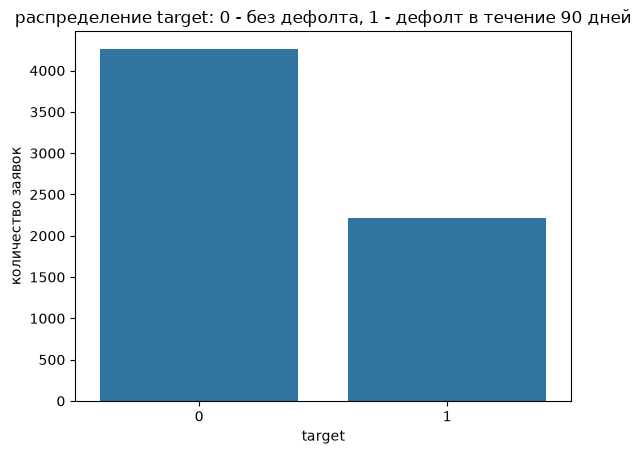

In [291]:
import seaborn as sns
import matplotlib.pyplot as plt 

sns.countplot(data=train, x='target')

plt.title("распределение target: 0 - без дефолта, 1 - дефолт в течение 90 дней")
plt.xlabel('target')
plt.ylabel('количество заявок')

plt.show

In [16]:
print(train['target'].value_counts(normalize=True))

target
0    0.657716
1    0.342284
Name: proportion, dtype: float64


Дисбаланс классов влияет на стратегию CV и обучение модели. Для равномерного распределения классов по фолдам я буду использовать далее StrarifieldKFold. Также я буду штрафовать модель сильнее за ошибки на классе 1

# Исследование признаков

## Демография: age, dependents, education

гипотеза: меньше возраст -> меньше опыта работы -> меньше заработок -> выше риск просрочки

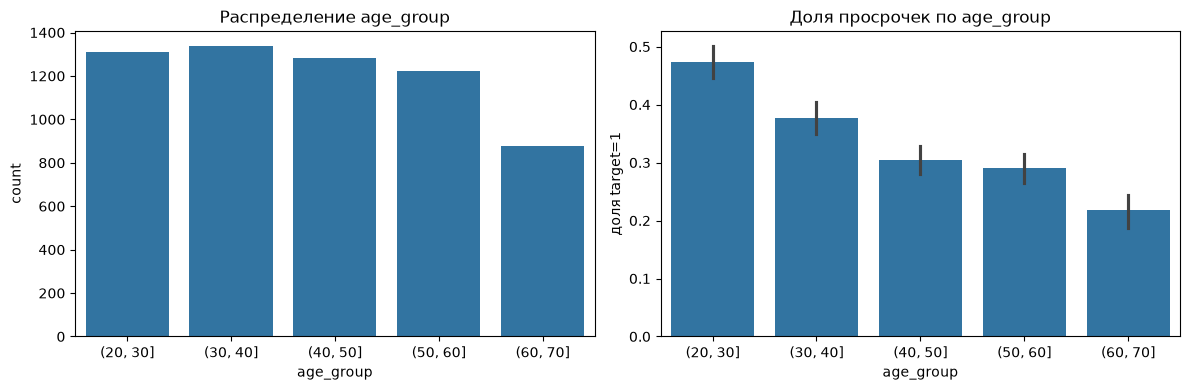

In [17]:
# разделение на группы по возрасту для визуализации
train['age_group'] = pd.cut(train['age'], bins=[20, 30, 40, 50, 60, 70])
visualization(train, 'age_group', 'target')

In [18]:
ttest('age', 'target', train)

p-value = 0.00000
η² (eta squared) = 0.0330


(np.float64(6.600531010485321e-46), np.float64(0.032999253583175035))

На графике монотонный, нелинейный тренд: молодые люди с большей вероятностью не выплачивают займ вовремя. Связь с target статистически значима (p~0), сила эффекта слабая по шкале Коэна (n^2 = 0.033). Оценка надежна. Гипотеза о связь возраста и риска просрочки подтверждена

гипотеза: больше иждивенцев -> рост нагрузки на бюджет -> выше риск выхода в просрочку

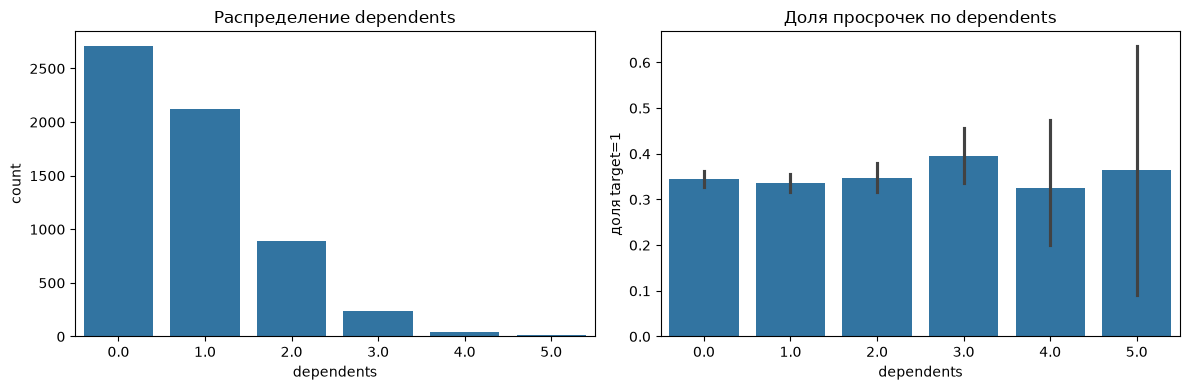

In [19]:
visualization(train, 'dependents', 'target')

In [20]:
chi2('dependents', 'target', train)

p-value = 0.6463, Cramer's V = 0.0255
ожидаемый уровень V при чистом шуме (H0) = 0.0304
expected.min() = 3.77


(np.float64(0.6462520937212135), np.float64(0.02553452569626568))

Тренда нет, связь статистически незначима (p~0.65), сила эффекта незначительна по шкале Коэна (V~0.025). Оценка ненадежна по редким категориям (3,4,5) из-за малого числа наблюдений. Гипотеза не подтверждена

гипотеза: выше уровень образования -> больше возможностей для картьерного роста -> выше доход -> меньше риск выйти в просрочку

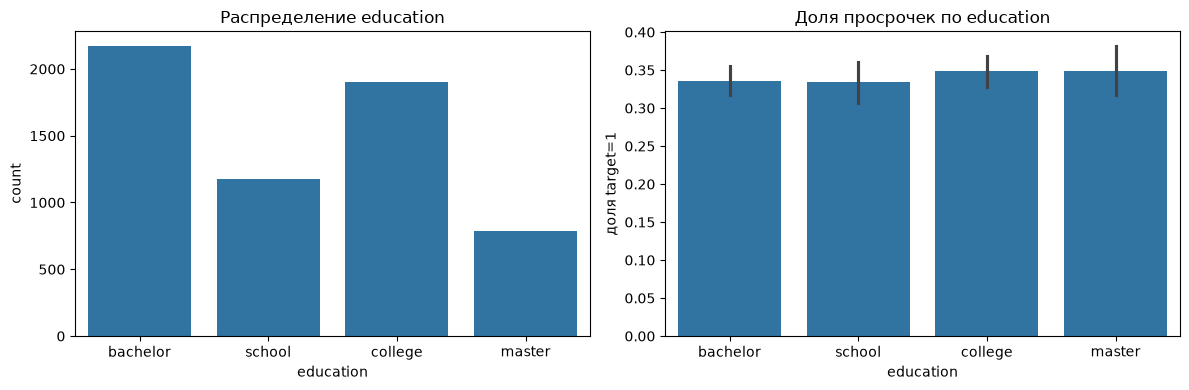

In [21]:
visualization(train, 'education', 'target')

In [22]:
chi2('education', 'target', train)

p-value = 0.7589, Cramer's V = 0.0170
ожидаемый уровень V при чистом шуме (H0) = 0.0248
expected.min() = 153.34


(np.float64(0.758943529518422), np.float64(0.017005213857729032))

Тренда нет, доля просрочки колеблется ~0.05. Связь статистически незначима (p~0.75), сила эффекта незначительная по шкале Коэна (V~0.017). Оценка надежна (expected.min = 153,34). Гипотеза не подтверждена

## Занятость и доход клиента

гипотеза: отсутствие работы -> отсутствие стабильного дохода -> выше риск выйти в просрочку

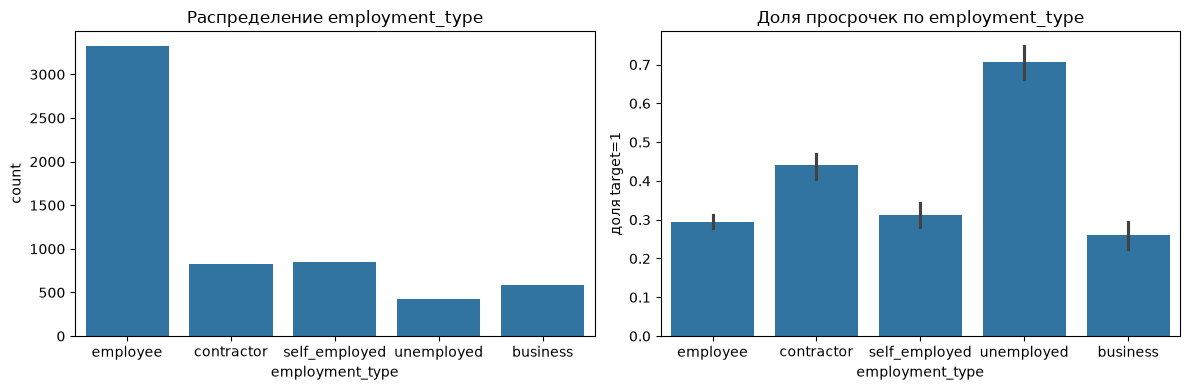

In [23]:
visualization(train, 'employment_type', 'target')

In [24]:
# доля просрочек по типу занятости

pd.crosstab(train['employment_type'], train['target'], normalize='index')

target,0,1
employment_type,,
business,0.738983,0.261017
contractor,0.560146,0.439854
employee,0.705140,0.294860
self_employed,0.689125,0.310875
unemployed,0.293706,0.706294


In [25]:
chi2('employment_type', 'target', train)

p-value = 0.0000, Cramer's V = 0.2296
ожидаемый уровень V при чистом шуме (H0) = 0.0278
expected.min() = 146.84


(np.float64(1.0613943407758955e-71), np.float64(0.22963961442401415))

В категории unemployed резкий выброс (70.6% просрочки против 26-44% у остальных категорий). Тип занятости статистически значимо связан с риском просрочки (p~0), эффект между слабым и умеренным по шкале Коэна (V=0.2296). Оценка надежна (expected.min ~ 146)

гипотеза: меньше рабочий стаж -> меньше карьерный рост -> меньше заработная плата -> выше риск просрочки

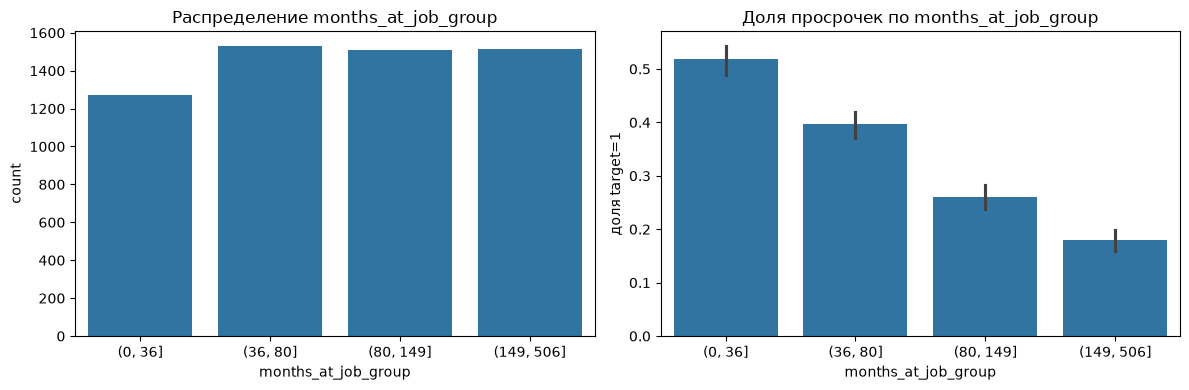

In [ ]:
visualization(train, 'months_at_job_group', 'target')

In [27]:
ttest('months_at_job', 'target', train)

p-value = 0.00000
η² (eta squared) = 0.0608


(np.float64(5.0214043403369645e-85), np.float64(0.06075523774423614))

Монотонный нелинейный тренд: чем меньше опыта работы, тем больше шанс выйти в просрочку. P-value подтверждает наличие связи (~0), n-квадрат (0.0608) демонстирует умеренную силу эффекта. Оценка надежна. Гипотеза подтверждена

**гипотеза: ниже доход -> выше риск просрочки**

montly_income и incoming_amount похожи, проверка на совпадения

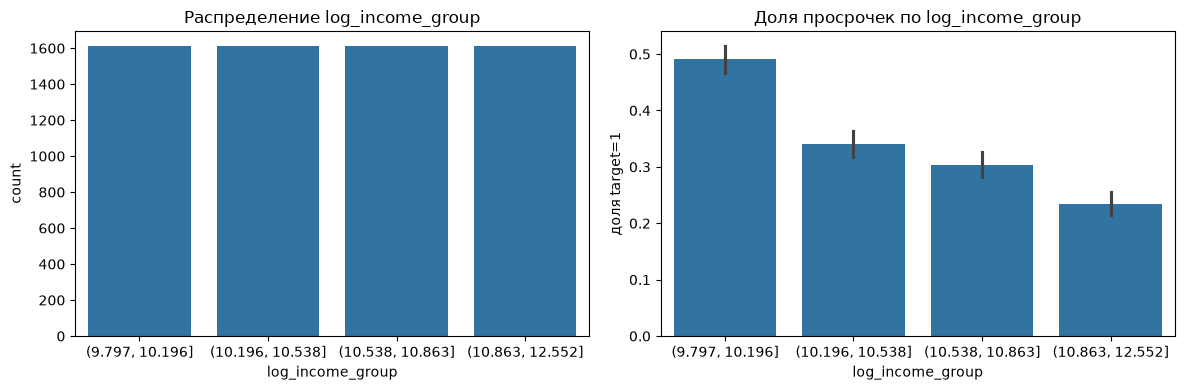

In [ ]:
visualization(train, 'log_income_group', 'target')

In [31]:
# доля просрочек в каждом квартиле

pd.crosstab(train['log_income_group'], train['target'], normalize='index')

target,0,1
log_income_group,,
"(9.797, 10.196]",0.508989,0.491011
"(10.196, 10.538]",0.659640,0.340360
"(10.538, 10.863]",0.696838,0.303162
"(10.863, 12.552]",0.765034,0.234966


In [32]:
# считаю ttest на логарифмированном доходе, т.к. данные внутри групп более симметричны
ttest('log_income', 'target', train)

p-value = 0.00000
η² (eta squared) = 0.0390


(np.float64(1.1337695782453097e-57), np.float64(0.038951035553621664))

Монотонный тренд: чем меньше доход, тем больше шанс выйти в просрочку. Основной эффект сосредоточен в группе с самым низким доходом (Q1: 49.4% просрочки против 23.8% в Q4). Статистически значимая связь (p-value~0), умеренная сила эффекта (n^2 ~ 0.039). Оценка надежна. Гипотеза подтверждена

## Параметры займа: loan_amount, loan_term_months, interest_rate

гипотеза: выше долг -> выше риск просрочки

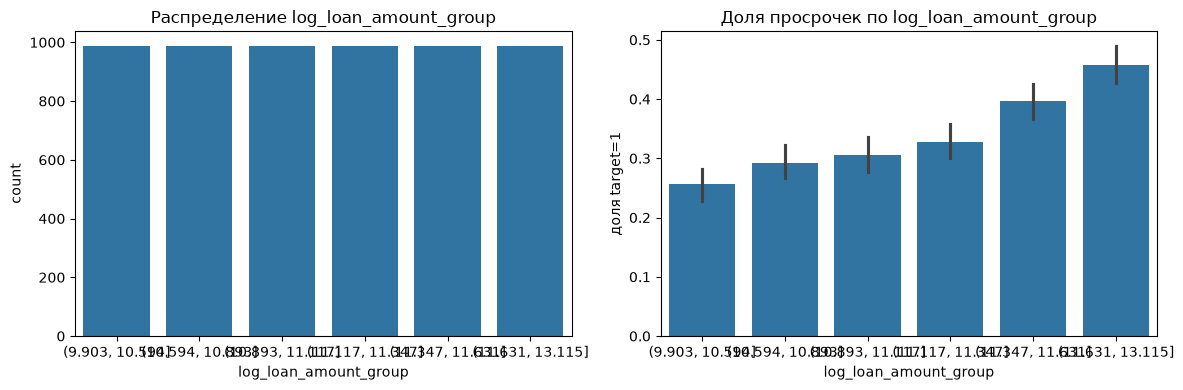

In [ ]:
visualization(train, 'log_loan_amount_group', 'target')

In [34]:
pd.crosstab(train['log_loan_amount_group'], train['target'], normalize='index')

target,0,1
log_loan_amount_group,,
"(9.903, 10.594]",0.743927,0.256073
"(10.594, 10.893]",0.707194,0.292806
"(10.893, 11.117]",0.695035,0.304965
"(11.117, 11.347]",0.671733,0.328267
"(11.347, 11.631]",0.603850,0.396150
"(11.631, 13.115]",0.542510,0.457490


In [35]:
ttest('log_loan_amount', 'target', train)

p-value = 0.00000
η² (eta squared) = 0.0223


(np.float64(7.625514571392809e-31), np.float64(0.022265985523081636))

In [36]:
# сравниваю разницу средних между группами с std внутри группы
# показывает, насколько сильно распределения пересекаются на уровне отдельного клиента
train.groupby('target')['log_loan_amount'].agg(['mean', 'std'])

,mean,std
target,,
0,11.060272,0.513104
1,11.228162,0.552624


Монотонный тренд: чем больше сумма займа, тем выше доля просрочки (25.6% в первом сегменте против 45.7% в последнем, рост постепенный по всем 6 группам). Связь статистически значима (p~0). Сила эффекта слабая по обеим шкалам (V=0.1382, η²=0.0223). Несмотря на выраженную разницу между крайними группами, разброс суммы займа внутри каждой группы target (std~0.51-0.55) в 3+ раза превышает разницу средних между группами (0.168), то есть сумма займа объясняет общий, групповой тренд риска, но слабо предсказывает исход для конкретного человека. Оценка надежна (expected.min()=190.31).

гипотеза: меньше срок кредита -> выше риск просрочки

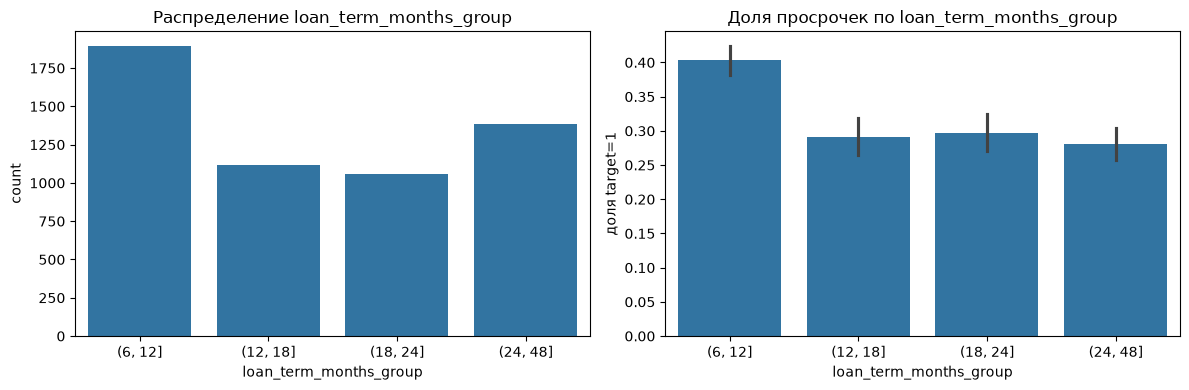

In [ ]:
visualization(train, 'loan_term_months_group', 'target')

In [38]:
# смотрю доли просрочек в каждом квартиле, в 1 больше всего
pd.crosstab(train['loan_term_months_group'], train['target'], normalize='index')

target,0,1
loan_term_months_group,,
"(6, 12]",0.596834,0.403166
"(12, 18]",0.708408,0.291592
"(18, 24]",0.702652,0.297348
"(24, 48]",0.719247,0.280753


In [39]:
ttest('loan_term_months', 'target', train)

p-value = 0.00000
η² (eta squared) = 0.0134


(np.float64(3.075420186498373e-19), np.float64(0.013414253770141799))

Связь не монотонная по всей шкале, сконцентрирована в одном сегменте: доля просрочки резко выше только у займов на самый короткий срок (6-12 мес, 40.3%), тогда как во всех более длинных сроках доля практически одинакова (28-30%). Связь статистически значима (p~0), но сила эффекта слабая (η²=0.0134), разброс срока внутри каждой группы target (std~11.7-11.9 мес) почти в 4 раза превышает разницу средних (2.9 мес), то есть отдельный человек с коротким/длинным сроком слабо предсказуем по этому признаку. Оценка надежна

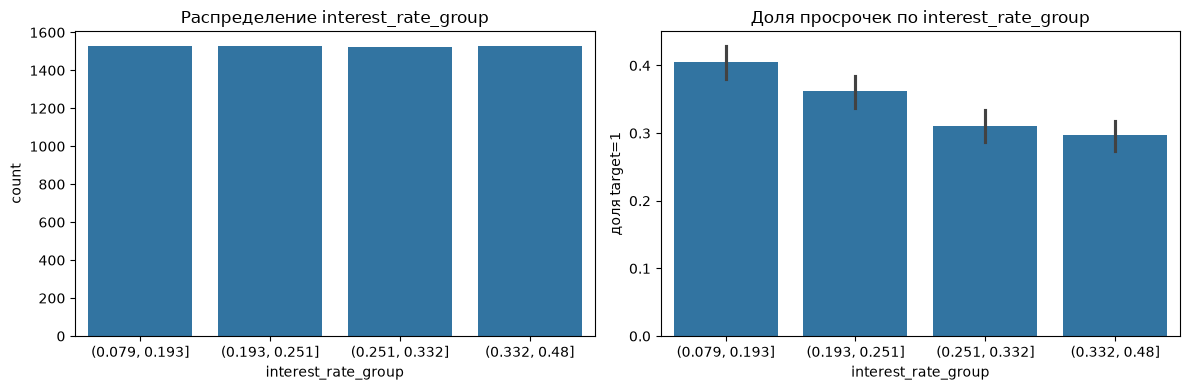

In [ ]:
visualization(train, 'interest_rate_group', 'target')

In [41]:
# разница средних vs std внутри группы
train.groupby('target')['interest_rate'].agg(['mean', 'std'])

,mean,std
target,,
0,0.275600,0.095914
1,0.259249,0.096206


In [42]:
ttest('interest_rate', 'target', train)

p-value = 0.00000
η² (eta squared) = 0.0065


(np.float64(2.8125630861138996e-10), np.float64(0.006500795765912046))

Монотонная, но контринтуитивная связь: доля просрочки снижается с ростом процентной ставки (40.5% в нижнем квартиле против 29.7% в верхнем) — обратное направление тому, что можно было бы ожидать. Связь статистически значима (p~0, оба теста), но эффект по величине минимален, ниже слабого порога (η^2=0.0065); разброс внутри групп почти в 6 раз превышает разницу средних. Возможно, направление связи объясняется косвенно — через корреляцию ставки с другими условиями займа (например, сроком), а не прямым влиянием на риск; стоит проверить это при построении модели. Оценка надёжна

гипотеза: риск просрочки не зависит от типа кредита

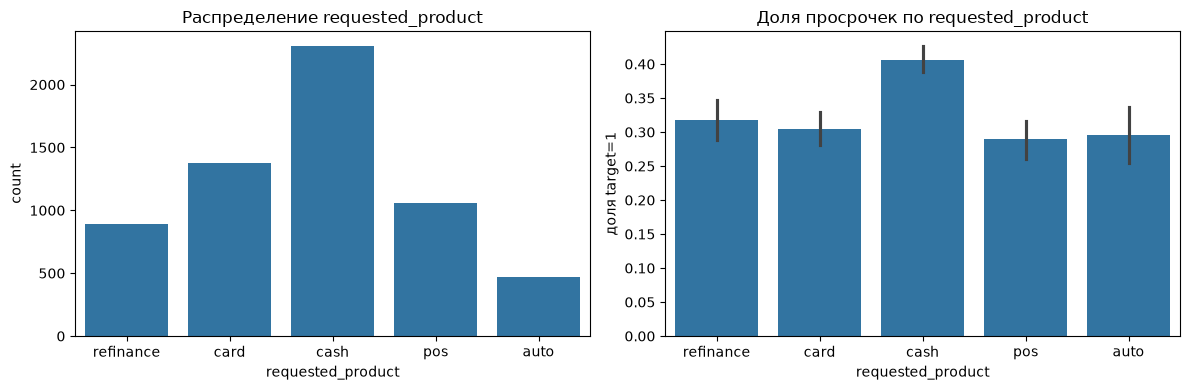

In [43]:
visualization(train, 'requested_product', 'target')

In [44]:
chi2('requested_product', 'target', train)

p-value = 0.0000, Cramer's V = 0.1044
ожидаемый уровень V при чистом шуме (H0) = 0.0278
expected.min() = 130.75


(np.float64(7.492449619152981e-14), np.float64(0.10441891651502741))

дописать вывод

## Регион: region, region_coefficient, region_coefficient_extended, siberia_northern_score

гипотеза: регион не влияет на риск просрочки

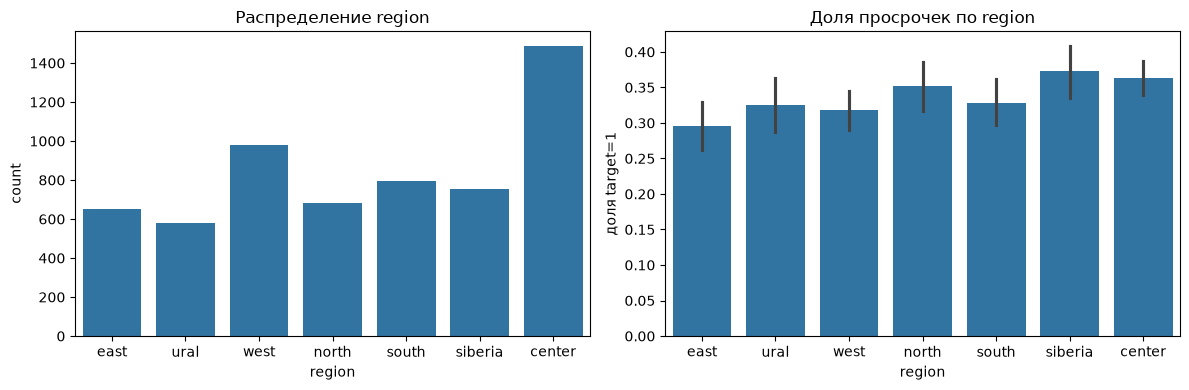

In [45]:
visualization(train, 'region', 'target')

In [46]:
chi2('region', 'target', train)

p-value = 0.0096, Cramer's V = 0.0535
ожидаемый уровень V при чистом шуме (H0) = 0.0329
expected.min() = 186.54


(np.float64(0.0096313045117296), np.float64(0.05353862672529161))

Тренда нет, не влияет

In [47]:
print(train['region_coefficient'].value_counts(dropna=False))
print('\n')
print(train.groupby('target')['region_coefficient'].apply(lambda x: x.isna().mean()))

# region_coefficient является бинарным флагом (1 или nan) 
# доля пропусков почти одинакова между классами
# не связан с nan

region_coefficient
1.0    6125
NaN     355
Name: count, dtype: int64


target
0    0.054200
1    0.055906
Name: region_coefficient, dtype: float64


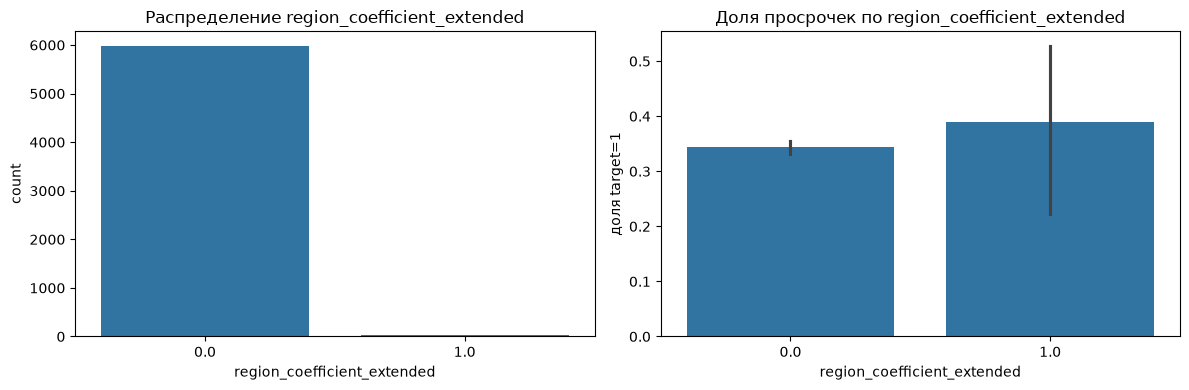

In [48]:
visualization(train, 'region_coefficient_extended', 'target')

In [49]:
# проверка распределения значений по группам target

train.groupby('target')['region_coefficient_extended'].value_counts(dropna=False)

target  region_coefficient_extended
0       0.0                            3922
        NaN                             318
        1.0                              22
1       0.0                            2061
        NaN                             143
        1.0                              14
Name: count, dtype: int64

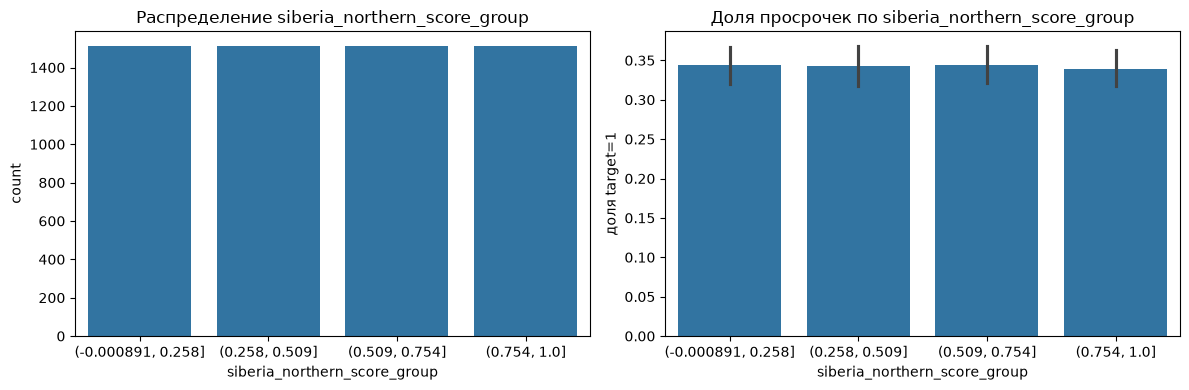

In [ ]:
visualization(train, 'siberia_northern_score_group', 'target')

In [51]:
ttest('siberia_northern_score', 'target', train)

p-value = 0.74113
η² (eta squared) = 0.0000


(np.float64(0.7411250272794542), np.float64(1.804701293595896e-05))

Тренда нет, cтатистически незначимая связь

## Канал/маркетинг 

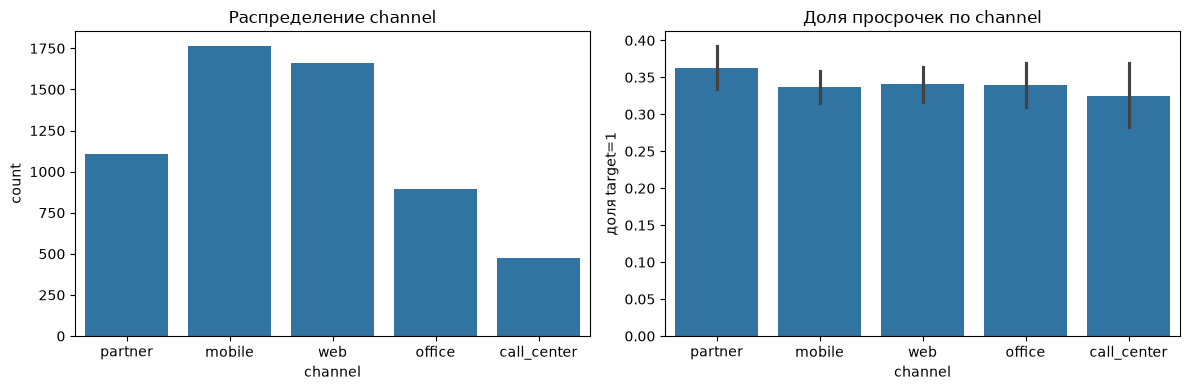

In [52]:
visualization(train, 'channel', 'target')

In [53]:
chi2('channel', 'target', train)

p-value = 0.6992, Cramer's V = 0.0215
ожидаемый уровень V при чистом шуме (H0) = 0.0278
expected.min() = 163.27


(np.float64(0.6992373793927055), np.float64(0.021533975544509393))

In [54]:
chi2('marketing_segment', 'target', train)

p-value = 0.8150, Cramer's V = 0.1440
ожидаемый уровень V при чистом шуме (H0) = 0.1521
expected.min() = 9.58


(np.float64(0.8149638934642448), np.float64(0.144005659095699))

# Выводы по EDA

In [55]:
eda_summary = pd.DataFrame([
    ('age',                        'ttest', '~0',       'n = 0.033',    'оставить',  'монотонный, нелинейный, надёжный тренд'),
    ('dependents',                 'chi2',      '0.646',    'V=0.026 (≈шум 0.030)', 'удалить',  'нет сигнала, хвост (3-5) ненадёжен'),
    ('education',                  'chi2',      '0.759',    'V=0.017',              'удалить',  'нет сигнала'),
    ('employment_type',            'chi2',      '~0',       'V=0.230',              'оставить',  'выброс: unemployed 70.6% против 26-44%'),
    ('months_at_job',              'ttest','~0',       'n=0.061',    'оставить',  'монотонный, но нелинейный (насыщается)'),
    ('income', 'ttest', '~0',  'V=0.197, η²=0.039',    'оставить', 'дублирующие источники, объединены (income_join); эффект сосредоточен в低ком доходе'),
    ('loan_amount',                'ttest','~0',       'n=0.022',    'оставить',  'монотонный, слабый, сильное внутригрупповое перекрытие; верхний бин широкий диапазон'),
    ('loan_term_months',           'ttest','~0',       'n=0.013',    'оставить',  'эффект сконцентрирован в самом коротком сроке (6-12 мес)'),
    ('interest_rate',              'ttest','~0',       'n=0.007',    'оставить', 'слабейший эффект, контринтуитивное направление — возможен confound со сроком'),
    ('requested_product',          'chi2',      '~0',       'V=0.104',              'оставить',  'нужно дописать markdown-вывод'),
    ('region',                     'chi2',      '0.0096',   'V=0.054',              'удалить',  'статистически значимо, но эффект пренебрежимо мал'),
    ('region_coefficient',         'manual',    '—',        '—',                    'удалить',  'бинарный флаг, доля NaN идентична между классами'),
    ('region_coefficient_extended','manual',    '—',        '—',                    'удалить',  'категория "1.0" слишком редкая (36 набл.)'),
    ('siberia_northern_score',     'ttest','0.998/0.741','n=0.0000', 'удалить',  'нет сигнала вообще'),
    ('channel',                    'chi2',      '0.699',    'V=0.022',              'удалить',  'нет сигнала, нужно дописать markdown-вывод'),
    ('marketing_segment',          'chi2',      '0.815',    'V=0.144 (≈шум 0.152)', 'удалить',  'высокая кардинальность, V на уровне шума, нужно дописать markdown-вывод'),
], columns=['feature', 'test', 'p_value', 'effect', 'verdict', 'comment'])


In [56]:
eda_summary

,feature,test,p_value,effect,verdict,comment
0,age,ttest,~0,n = 0.033,оставить,"монотонный, нелинейный, надёжный тренд"
1,dependents,chi2,0.646,V=0.026 (≈шум 0.030),удалить,"нет сигнала, хвост (3-5) ненадёжен"
2,education,chi2,0.759,V=0.017,удалить,нет сигнала
3,employment_type,chi2,~0,V=0.230,оставить,выброс: unemployed 70.6% против 26-44%
4,months_at_job,ttest,~0,n=0.061,оставить,"монотонный, но нелинейный (насыщается)"
5,income,ttest,~0,"V=0.197, η²=0.039",оставить,"дублирующие источники, объединены (income_join..."
6,loan_amount,ttest,~0,n=0.022,оставить,"монотонный, слабый, сильное внутригрупповое пе..."
7,loan_term_months,ttest,~0,n=0.013,оставить,эффект сконцентрирован в самом коротком сроке ...
8,interest_rate,ttest,~0,n=0.007,оставить,"слабейший эффект, контринтуитивное направление..."
9,requested_product,chi2,~0,V=0.104,оставить,нужно дописать markdown-вывод


In [ ]:
features_to_drop = [
    'region', 'region_coefficient', 'region_coefficient_extended',
    'siberia_northern_score', 'channel', 'marketing_segment', 
    'dependents', 'education',

    # # удаляю признаки, сделанные для визуализации
    'age_group', 'months_at_job_group', 'log_income_group',
    'log_loan_amount_group', 'loan_term_months_group', 
    'interest_rate_group', 'siberia_northern_score_group',
    

    # и объединенные и логарифмированные признаки
    'incoming_amount', 'monthly_income', 'loan_amount', 'income',

    # # бесполезный признак
    'application_date',
    
]

train = train.drop(columns=features_to_drop, errors='ignore')
test = test.drop(columns=features_to_drop, errors='ignore')

Разведочный анализ данных показал, что наиболее значимыми по силе эффекта признаками оказались занятость, доход, срок займа и стаж заемщика. Демографические (иждивенцы, образование), географические (регион, коэффиценты региона) и маркетинговые признаки (канал, маркетниговый сегмент) не показали сигнал связи с риском. Ни один отдельный признак не дал сильного эффекта (максимум V = 0.262). Модель должна опираться на комбинацию признаков. 

Инсайты: 

1. interest_rate - контринтуитивное направление связи для процента ставки

Данные из transactions.csv, bureau.csv, previous_loans.csv будут проанализированы следующим шагом

анализ по добавленным колонкам

In [58]:
def feature_significance_table(features, target, data):
    results = []
    for col, kind in features:
        if kind == 'continuous':
            p, effect = ttest(col, target, data, verbose=False)
            test_name = 'ttest'
        else:
            p, effect = chi2(col, target, data, verbose=False)
            test_name = 'chi2'
        results.append({'feature': col, 'test': test_name, 'p_value': p, 'effect': effect})
    return pd.DataFrame(results).sort_values('effect', ascending=False).reset_index(drop=True)

features = [
    ('transactions_count', 'continuous'),
    ('transactions_amount_sum', 'continuous'),
    ('transactions_amount_mean', 'continuous'),
    ('transactions_risk_mean', 'continuous'),
    ('cash_withdrawal', 'continuous'),
    ('gambling', 'continuous'),
    ('groceries', 'continuous'),
    ('entertainment', 'continuous'),
    ('loan_payment', 'continuous'),
    ('salary', 'continuous'),
    ('transfer', 'continuous'),
    ('utilities', 'continuous'),
    ('days_since_last_transactions', 'continuous'),
    ('bureau_account_id_count', 'continuous'),
    ('credit_limit_sum', 'continuous'),
    ('credit_limit_mean', 'continuous'),
    ('credit_limit_max', 'continuous'),
    ('credit_limit_min', 'continuous'),
    ('current_balance_sum', 'continuous'),
    ('current_balance_mean', 'continuous'),
    ('current_balance_max', 'continuous'),
    ('current_balance_min', 'continuous'),
    ('max_dpd_last_12m_max', 'continuous'),
    ('bureau_active_status', 'continuous'),
    ('auto', 'continuous'),
    ('consumer', 'continuous'),
    ('credit_card', 'continuous'),
    ('microloan', 'continuous'),
    ('mortgage', 'continuous'),
    ('previous_loan_count', 'continuous'),
    ('previous_amount_mean', 'continuous'),
    ('previous_amount_min', 'continuous'),
    ('previous_amount_max', 'continuous'),
    ('previous_term_months_mean', 'continuous'),
    ('previous_term_months_max', 'continuous'),
    ('closed_days_ago_min', 'continuous'),
    ('was_overdue_mean', 'continuous'),
    ('max_overdue_days', 'continuous'),
    ('has_bureau', 'categorical'),
    ('has_previous_loans', 'categorical'),
]


table = feature_significance_table(features, 'target', train)
table[['p_value', 'effect']] = table[['p_value', 'effect']].round(5)

table

,feature,test,p_value,effect
0,max_dpd_last_12m_max,ttest,0.00000,0.11873
1,has_bureau,chi2,0.00000,0.10671
2,max_overdue_days,ttest,0.00000,0.02980
3,has_previous_loans,chi2,0.04744,0.02463
4,bureau_account_id_count,ttest,0.00000,0.01084
5,was_overdue_mean,ttest,0.00000,0.00879
6,current_balance_sum,ttest,0.00000,0.00690
7,credit_limit_sum,ttest,0.00000,0.00432
8,credit_limit_min,ttest,0.00000,0.00370
9,current_balance_max,ttest,0.00003,0.00282


При большой выборке наблюдений p-value будет стремиться к нулю. Дропаю признаки с незначительным эффектом (n^2 < 0.01 по Крамеру). 

In [ ]:
# данные скошены вправо выбросами с высоким cash_flow, логарифмирую для симметрии 
train['cash_flow'].skew()) # ~1.62
train['cash_flow_log'] = np.log1p(train['cash_flow'])

In [59]:
features_to_drop = [
    'transactions_count', 'transactions_amount_sum', 'transactions_amount_mean', 'transactions_risk_mean',
    'cash_withdrawal', 'gambling', 'groceries', 'entertainment', 'loan_payment', 'salary', 'transfer', 'utilities',
    'days_since_last_transactions', 'credit_limit_sum', 'credit_limit_mean', 'credit_limit_max', 'credit_limit_min',
    'current_balance_sum', 'current_balance_mean', 'current_balance_max', 'current_balance_min',
    'bureau_active_status', 'auto', 'consumer', 'credit_card', 'microloan', 'mortgage',
    'previous_loan_count', 'previous_amount_mean', 'previous_amount_min', 'previous_amount_max',
    'previous_term_months_mean', 'previous_term_months_max', 'closed_days_ago_min', 'was_overdue_mean',
]

train = train.drop(columns=features_to_drop)
test = test.drop(columns=features_to_drop)


работа с нан значениями

In [294]:
train.isna().sum()

application_id                    0
client_id                         0
employment_type                 465
region_coefficient_extended     461
age                             449
                               ... 
was_overdue_mean               1557
max_overdue_days_max           1605
max_overdue_days_sum           1506
last_loan_was_overdue          1557
last_loan_max_overdue_days     1605
Length: 71, dtype: int64

In [61]:
train.isna().sum(axis=1).value_counts().sort_index()

0    2757
1    2377
2    1004
3     281
4      52
5       8
6       1
Name: count, dtype: int64

In [295]:
# пропуски не имеют структурной причины MCAR 

# заполняю пропуски отдельной категорией unknown для категориальных признаков
train['employment_type'] = train['employment_type'].fillna('unknown')
train['requested_product'] = train['requested_product'].fillna('unknown')

# заполняю медианой - устойчива к выбросам
train['age'] = train['age'].fillna(train['age'].median())
train['log_income'] = train['log_income'].fillna(train['log_income'].median())
train['log_loan_amount'] = train['log_loan_amount'].fillna(train['log_loan_amount'].median())
train['interest_rate'] = train['interest_rate'].fillna(train['interest_rate'].median())
train['months_at_job'] = train['months_at_job'].fillna(train['months_at_job'].median())
train['loan_term_months'] = train['loan_term_months'].fillna(train['loan_term_months'].median())

# пропуски связаны с отсутствием информации MNAR

train['bureau_account_id_count'] = train['bureau_account_id_count'].fillna(0)
train['max_dpd_last_12m_max'] = train['max_dpd_last_12m_max'].fillna(-1)
train['max_overdue_days'] = train['max_overdue_days'].fillna(-1)


KeyError: 'max_overdue_days'

In [63]:
# категориальные - заполняю той же меткой 'unknown', что и в train
test['employment_type'] = test['employment_type'].fillna('unknown')
test['requested_product'] = test['requested_product'].fillna('unknown')

# числовые - используем медианы, посчитанные на train (а не на test!), чтобы препроцессинг был согласован
test['age'] = test['age'].fillna(train['age'].median())
test['log_income'] = test['log_income'].fillna(train['log_income'].median())
test['log_loan_amount'] = test['log_loan_amount'].fillna(train['log_loan_amount'].median())
test['interest_rate'] = test['interest_rate'].fillna(train['interest_rate'].median())
test['months_at_job'] = test['months_at_job'].fillna(train['months_at_job'].median())
test['loan_term_months'] = test['loan_term_months'].fillna(train['loan_term_months'].median())

# MNAR - те же метки, что и в train
test['bureau_account_id_count'] = test['bureau_account_id_count'].fillna(0)
test['max_dpd_last_12m_max'] = test['max_dpd_last_12m_max'].fillna(-1)
test['max_overdue_days'] = test['max_overdue_days'].fillna(-1)


In [64]:
test.isna().sum()

application_id             0
client_id                  0
loan_term_months           0
months_at_job              0
employment_type            0
age                        0
interest_rate              0
requested_product          0
bureau_account_id_count    0
max_dpd_last_12m_max       0
has_bureau                 0
max_overdue_days           0
has_previous_loans         0
log_income                 0
log_loan_amount            0
dtype: int64

encoding

In [296]:
from sklearn.preprocessing import OneHotEncoder

cat_cols = ['employment_type', 'requested_product']

encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
encoder.fit(train[cat_cols])  # обучаем только на train

train_encoded = pd.DataFrame(
    encoder.transform(train[cat_cols]),
    columns=encoder.get_feature_names_out(cat_cols),
    index=train.index,
)
test_encoded = pd.DataFrame(
    encoder.transform(test[cat_cols]),
    columns=encoder.get_feature_names_out(cat_cols),
    index=test.index,
)

train = pd.concat([train.drop(columns=cat_cols), train_encoded], axis=1)
test = pd.concat([test.drop(columns=cat_cols), test_encoded], axis=1)


обучение модели

In [303]:
X = train.drop(columns=['target', 'client_id', 'application_id'])
y = train['target']

In [298]:
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier

from sklearn.metrics import roc_auc_score

log_reg = LogisticRegression(class_weight='balanced', solver='saga', max_iter=5000, penalty='l1', C=0.1, random_state=1)
random_forest = RandomForestClassifier(class_weight='balanced', n_estimators=200, min_samples_split=20, min_samples_leaf=1, max_depth=None, random_state=1)
lgmm = LGBMClassifier(num_leaves=15, n_estimators=500, min_child_samples=50, learning_rate=0.01, random_state=1)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


def cv_score(model, x, y, skf=skf):
    roc_aucs = []

    for fold, (train_index, test_index) in enumerate(skf.split(x, y)):
        X_train, X_test = x.iloc[train_index], x.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        model.fit(X_train_scaled, y_train)

        preds = model.predict_proba(X_test_scaled)[:, 1]
        roc_auc = roc_auc_score(y_test, preds)

        roc_aucs.append(roc_auc)

        print(f"Фолд: {fold+1}: roc_auc = {roc_auc:.4f}")

    print(f"Средний roc-auc по всем фолдам: {np.mean(roc_aucs):.4f}")
    return np.mean(roc_aucs), roc_aucs

In [304]:
cv_score(random_forest, X, y)

ValueError: Input X contains infinity or a value too large for dtype('float64').

In [300]:
cv_score(log_reg, X, y)

ValueError: could not convert string to float: 'bachelor'

In [301]:
cv_score(lgmm, X, y)

ValueError: could not convert string to float: 'bachelor'

In [76]:
from sklearn.model_selection import RandomizedSearchCV

param_dist_lgbm = {
    'n_estimators': [100, 200, 300, 500],
    'num_leaves': [15, 31, 63, 127],
    'learning_rate': [0.01, 0.05, 0.1],
    'min_child_samples': [5, 10, 20, 50],
}


lgmm = LGBMClassifier(random_state=42)

search = RandomizedSearchCV(
    estimator=lgmm,
    param_distributions=param_dist_lgbm,
    n_iter=30,                 # сколько случайных комбинаций параметров перебрать
    scoring='roc_auc',
    cv=skf,                    # тот же StratifiedKFold, что и раньше
    random_state=42,
    n_jobs=-1,                 # использовать все ядра процессора
)

search.fit(X, y)

print('Лучшие параметры:', search.best_params_)
print('Лучший CV roc_auc:', search.best_score_)


[LightGBM] [Info] Number of positive: 1774, number of negative: 3410[LightGBM] [Info] Number of positive: 1774, number of negative: 3410
[LightGBM] [Info] Number of positive: 1774, number of negative: 3410
[LightGBM] [Info] Number of positive: 1774, number of negative: 3410
[LightGBM] [Info] Number of positive: 1774, number of negative: 3410

[LightGBM] [Info] Number of positive: 1774, number of negative: 3410
[LightGBM] [Info] Number of positive: 1775, number of negative: 3409
[LightGBM] [Info] Number of positive: 1775, number of negative: 3409
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002255 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003485 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Auto-choosing col-wise multi-threading, th

In [77]:
from sklearn.model_selection import RandomizedSearchCV

param_dist_rf = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_leaf': [1, 5, 10, 20, 50],
    'min_samples_split': [2, 10, 20],
}

random_forest = RandomForestClassifier(class_weight='balanced', random_state=42)

search = RandomizedSearchCV(
    estimator=random_forest,
    param_distributions=param_dist_rf,
    n_iter=30,                 # сколько случайных комбинаций параметров перебрать
    scoring='roc_auc',
    cv=skf,                    # тот же StratifiedKFold, что и раньше
    random_state=42,
    n_jobs=-1,                 # использовать все ядра процессора
)

search.fit(X, y)

print('Лучшие параметры:', search.best_params_)
print('Лучший CV roc_auc:', search.best_score_)

Лучшие параметры: {'n_estimators': 200, 'min_samples_split': 20, 'min_samples_leaf': 1, 'max_depth': None}
Лучший CV roc_auc: 0.8264689840003581


In [80]:
from sklearn.pipeline import make_pipeline

param_dist_logreg = {
    'logisticregression__C': [0.001, 0.01, 0.1, 1, 10, 100],
    'logisticregression__penalty': ['l1', 'l2'],
}

log_reg_pipeline = make_pipeline(
    StandardScaler(),
    LogisticRegression(class_weight='balanced', solver='saga', max_iter=5000, random_state=42),
)

search_logreg = RandomizedSearchCV(
    estimator=log_reg_pipeline,
    param_distributions=param_dist_logreg,
    n_iter=12,
    scoring='roc_auc',
    cv=skf,
    random_state=42,
    n_jobs=-1,
)

search_logreg.fit(X, y)

print('Лучшие параметры:', search_logreg.best_params_)
print('Лучший CV roc_auc:', search_logreg.best_score_)


/opt/anaconda3/envs/study/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/opt/anaconda3/envs/study/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/opt/anaconda3/envs/study/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf

Лучшие параметры: {'logisticregression__penalty': 'l1', 'logisticregression__C': 0.1}
Лучший CV roc_auc: 0.825597819497489


/opt/anaconda3/envs/study/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/opt/anaconda3/envs/study/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
